# Calculate isostatic flexure at a Badlands time step

###################################################################################################################################################################################################
# By: Andres Rodriguez Corcho, Claire Mallard, Sara Polanco, Camilo Montes, Louis Moresi
# The University of Sydney 2026
# Email: andres.rodriguez1@sydney.edu.au
###################################################################################################################################################################################################

# This code:

1. Calculates the water thickness 
2. Calculates the change in water elevation between consecutive time steps 
3. Computes the isostatic response associated to water thickness change
4. Plots the spatial distribution of the isostatic response at a give time step



In [22]:
import gflex
import pandas as pd
import numpy as np
import re 
import matplotlib.mlab as ml
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.offsetbox import AnchoredText
#from scripts import morphoGrid_sl as morph
from scipy.spatial import cKDTree
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import time
from IPython.display import Image


# display plots in SVG format
%config InlineBackend.figure_format = 'svg'
%matplotlib inline

In [4]:
#Image('/live/share/Badlands_simulations/Delta_2020/Delta_analysis/hydroisostasy/figures/hydroisostasy_cartoon.jpg', width=400, height=400)

### Set up Parameters

In [5]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#%matplotlib

saveDir='./Post_processing/Produciton_post_processing_final/Raw_PDFs/'
dataFT='/live/user_data/Arc-Collision_Bdls/Post_processing/Post_processing/Produciton_post_processing_final/'
dataCorr='/Correlation/'

dataEro="/EroDepo_Evolution_/"
EroSeed="'eroAvg_evo_"
BdFields=["EroDep","Elevation","Discharge"]

### Get regular grid from simulations.

This grid, which will be clipped at the location of the basin, will be used to calculate the flexure using gflex.

In [6]:
#This function check the number of time steps in the specified directory
def getNumSteps(FolderDir,model,DataDir,FileSeed,max_ts=200):
    directory_name = FolderDir+model+DataDir
    Nsteps=0
    for i in range(max_ts):
        #print(FileSeed,i)
        file_name =FileSeed+ str(i) + '.csv'
        try:
            with open(directory_name + file_name, mode = 'r')as file: 
                Nsteps=Nsteps+1
        except FileNotFoundError:
            #print("File not found {0}".format(directory_name + file_name))
            break
    return Nsteps

#getNumSteps(FolderDir,model,DataDir ,FileSeed)
#getNumSteps(dataFT, "HighEro",'/EroDepo_Evolution_/','eroD_evo_')
#getNumSteps(dataFT,"HighEro", '/Correlation/' ,'0km_slice_')

import csv
import numpy as np
def compute_UwVar(FolderDir, model,FileSeed,Uw_var,
                  maxX,minX,
                  step_time=0.2,total_ts=200):
    
     #maximum possible number of steps
    DataDir='/Correlation/' 
    directory_name = FolderDir+model+DataDir#path to paraView output
    ts_interval = step_time
    
    #######################################################
    # this counts the number of files in the directoty - do not matter about the structure
    #print(FolderDir,model, FileSeed,total_ts)
    num_of_dataFile = getNumSteps(FolderDir,model,DataDir ,FileSeed,total_ts)
    ######################################################
    
    model_width_ls = int(np.abs(maxX-minX)) #width of the slice
    #print(maxX,minX)
    #time_ls = 0 #last timestep read 
    #strainID_raw = [] #list of strain rate values 
    
    uwData=np.zeros((num_of_dataFile,model_width_ls)) #Numpy array which will be ploted using imshow
    #xIDs=[] # Xs IDs of the data
    
    #Ratio between number of data per time and 512 which is the model length.A not integer ratio means that there are less than
    #values in one time step
    #lens=[]
    
    #########################################################################################################
    #Actual num_dataFile
    TotalData=num_of_dataFile
    #go through all .csv files
    Nsteps=0
    for i in range(num_of_dataFile):
        file_name =FileSeed+ str(i) + '.csv'
        
        uw_aux=[]
        uw_x_aux=[]  
        #print(file_name)
        try:
            with open(directory_name + file_name, mode = 'r')as file: #Open .csv file with i time step
                reader = csv.DictReader(file)
                ct = 0 #regular counter to loop in all rows
                #record all Uw values (eg. strain rate) along the slice
                for row in reader:
                          
                    
                    try:
                        
                        ###################################
                        ##### DATA AND X POSITIONS OF CURRENT TIME STEP-FILE
                        uw_aux.append(float(row[Uw_var]))
                        uw_x_aux.append(float(row['Points:0']))
                    except KeyError:
                        #print("error_"+str(i))
                        TotalData=TotalData-1
                        break
                    ct +=1 
                    
        except FileNotFoundError:
            #print("File not found {0}".format(file_name))
            break
    #########################################################################################################
        uw_aux=np.array(uw_aux)
        uw_x_aux=np.array(uw_x_aux)
        
        ## INTERPOLATION FUNCTION FOR THE UW VARIABLE IN FUNCTION OF THE X COORDINATES
        f = interpolate.interp1d(uw_x_aux, uw_aux,kind="linear")  
         ### INTERPOLATE VARIABLES WITHIN THE SELECTED X INTERVAL
        Xnew = np.linspace(minX, maxX,int(model_width_ls))
        uW_new = f(Xnew)
        
        #print(ct,model_width_ls,Nsteps)
        ###################################
        ## ADD TO ARRAY
        uwData[Nsteps]=uW_new
        
        Nsteps=Nsteps+1

    ##########################
    ## THIS REVERSES THE ARRAY IN STRATIGRAPHIC ORDER
    uwData = uwData[::-1]
    ##########################
    #uwData = np.array(uwData, dtype= float) #conversion into numpy array
    
    #try:
    Min=np.amin(uwData)
    Max=np.amax(uwData)
        
    return uwData,model_width_ls,Nsteps,Min,Max

In [7]:
#compute_UwVar(dataFT, "HighEro",'0km_slice_',"strainRateField",600.,-400.)

In [8]:
#This funcion loads all Bdls slices from an specified directoy, then interpolates them to match the size of the UW
#slices data, finally exports a numpy array which can be used do visualize the EroDepo evolution
import csv
import numpy as np
from scipy import interpolate
def compute_EroDepo_Elev(FolderDir, model,FileSeed="eroD_evo_",maxX=None,minX=None,step_time=0.2,total_ts=200):
    #total_ts = total_steps
    ts_interval = step_time
    
    #yaxis_label_interval = ts_interval*10
    
    #-------------------------#
    #functions to get data    # 
    #-------------------------#
    #######################################################
    DataDir='/EroDepo_Evolution_/' 
    directory_name = FolderDir+model+DataDir #path to paraView output
    # this counts the number of files in the directoty - do not matter about the structure
    num_of_dataFile = getNumSteps(FolderDir,model,DataDir, FileSeed,total_ts)
    #######################################################
    
    Cmodel_width_ls=int(np.abs(maxX-minX)) #width of the slice
    
    #model_width_ls = 0 #width of the slice
    #time_ls = 0 #last timestep read 
    
    EroDepoData=np.zeros((num_of_dataFile,Cmodel_width_ls)) #Numpy array which will be ploted using imshow
    ElevationData=np.zeros((num_of_dataFile,Cmodel_width_ls)) #Numpy array which will be ploted using imshow
    
    avrElev=np.array([]) #list with average elevations
    

    #Actual num_dataFile
    TotalData=num_of_dataFile
    #go through all .csv files
    
    Nsteps=0
    
    for i in range(num_of_dataFile):

        file_name =FileSeed+ str(i) + '.csv'
        #file_name =FileSeed+'_' + str(i) + '.csv'
        
        auxEroDepo=[]
        auxElev=[]
        #auxSlvl=[]
        auxX_coord=[]

        try:
            with open(directory_name + file_name, mode = 'r')as file: #Open .csv file with i time step
                reader = csv.DictReader(file)
                ct = 0 #regular counter to loop in all rows
                #record all strain rate values along the slice
                for row in reader:
                    
                    try:
                        #Raw data from Badlands surface
                        auxEroDepo.append(float(row["EroDep"]))
                        auxX_coord.append(float(row["Points:0"]))
                        auxElev.append(float(row["Elevation"]))
                        #auxSlvl.append(float(row["Sealevel"]))
                    except KeyError:
                        print("error_"+str(i))
                        TotalData=TotalData-1
                        break
                    ct +=1 
                
                #Making numpy arrays
                auxEroDepo=np.array(auxEroDepo)
                auxX_coord=np.array(auxX_coord) #THIS IS IN METERS
                auxElev=np.array(auxElev)
                #Interpolation Ero-Depo 
                f = interpolate.interp1d(auxX_coord/1e3, auxEroDepo,kind="linear")  
                #Interpolation Elevation
                fElev= interpolate.interp1d(auxX_coord/1e3, auxElev,kind="linear")
                
                ############################################################
                ### INTERPOLATE VARIABLES WITHIN THE SELECTED X INTERVAL
                Xnew = np.linspace(minX, maxX,int(Cmodel_width_ls)) ###XMIN AND XMAX ARE IN KMS
                EroDepo_new = f(Xnew)
                Elev_new = fElev(Xnew)
                ############################################################
                        
        except FileNotFoundError:
            #print("File not found {0}".format(file_name))
            break

        #### ADDING DATA TO THE BIG NUMPY ARRAY
        EroDepoData[Nsteps]=EroDepo_new 
        ElevationData[Nsteps]=Elev_new
        Nsteps=Nsteps+1


    print("Ero-Depo loaded")

    
    try:
        Min=np.amin(EroDepoData)
        Max=np.amax(EroDepoData)
        
        MinEl=np.amin(ElevationData)
        MaxEl=np.amax(ElevationData)
        
    except ValueError:
        pass
    
    ###############################
    ## THIS REVERSES THE ARRAY IN STRATIGRAPHIC ORDER
    #EroDepoData = EroDepoData[::-1]
    #ElevationData = ElevationData[::-1]
    ###############################
    #return 0
    return EroDepoData,Nsteps,Min,Max,ElevationData,MinEl,MaxEl, Xnew

### Taking sections of a single time step

In [9]:
time = 35 #Myr
step = time / 0.2 # 200 Myr is the time step

#Get data profiles of all time steps

eroDep, MinEroDep, MaxEroDep= compute_EroDepo_Elev(dataFT, "MedEro","eroAvg_evo_",580.,120.)[0:3]

elevation, MinElev, MaxElev, Xnew_ = compute_EroDepo_Elev(dataFT, "MedEro","eroAvg_evo_",580.,120.)[4:]

#Select desired timestep
#step=2
eroDep_final = eroDep[int(step)]

elevation_final = elevation[int(step)]

Ero-Depo loaded
Ero-Depo loaded


In [10]:
np.shape(eroDep_final)

(460,)

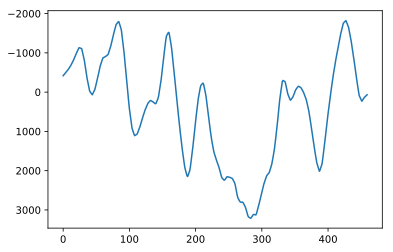

In [11]:
import matplotlib.pyplot as plt

plt.plot(eroDep_final)
plt.gca().invert_yaxis()
plt.show()

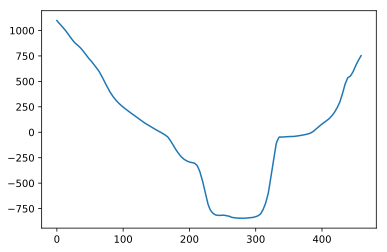

In [12]:
plt.plot(elevation_final)
plt.show()

### Calculation of flexure based on Sara's script

In [117]:
# Parameters for gflex

poisson = 0.25 #Dont change
youngMod = 100e9 #Dont change 
mantleDensity = 3300.0 
sedimentDensity = 2993.376 #Change to my value..
elasticT = 50.

########################################################################
#Boundary conditions - '0Displacement0Slope'
# Makes the elastic thickness to have a small effect on the flexure
boundary_W =  '0Displacement0Slope' #'Mirror'
boundary_E = '0Displacement0Slope' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  '0Slope0Shear' #'Mirror'
boundary_E = '0Slope0Shear' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

#0Slope0Shear

#path='/live/share/Badlands_simulations/Delta_2020'

simStep = 200  # The number of steps in your simulation
dx = 1e4 # The resolution you want based on your simulation
dy = 1e4

In [139]:
#Define a function to compute the isostatic response associated to water thickness change¶
def getSedimentChangeFlex(SedimentDH, ElThick ,boundary_W,boundary_E,boundary_S,boundary_N ):
    
    flex = gflex.F2D()
    # Set-up the grid variable
    flex.dx = dx
    flex.dy = dy

    # Solution method finite difference
    flex.Method = "FD"
    flex.Quiet = True

    # van Wees and Cloetingh (1994)
    flex.PlateSolutionType = "vWC1994"
    flex.Solver = "direct"

    # Acceleration due to gravity
    flex.g = 9.8
    # Poisson's Ratio
    flex.nu = poisson
    # Infill Material Density
    flex.rho_fill = 0.0
    # Young's Modulus
    flex.E = youngMod
    # Mantle Density
    flex.rho_m = mantleDensity
    # Sediment Density
    rho_s = sedimentDensity
    # Sea Water Density
    #rho_w = 1029.0

    Te = ElThick * np.ones(SedimentDH.shape)

    flex.Te = Te
    
    

    # Surface load stresses
    flex.qs = np.zeros(SedimentDH.shape, dtype=float)

    # Boundary conditions
    flex.BC_W = boundary_W
    flex.BC_E = boundary_E
    flex.BC_S = boundary_S
    flex.BC_N = boundary_N

    # Compute surface loads
    flex.qs = (rho_s * flex.g * SedimentDH) #Here is rho sediment and waterDH is changed by sediment thickness
    
    flex.initialize()
    flex.run()
    flex.finalize()
    
    #print(flex.w)
    
    return flex.w

#SedimentDH is the ero-depo grid

In [119]:
len(Xnew_)

460

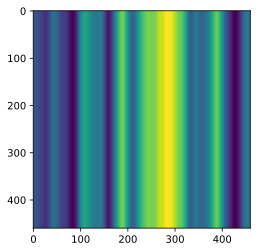

In [120]:
eroDep_final2=np.tile(eroDep_final.copy(), 
                      460).reshape(len(eroDep_final),460)


#eroDep_final2[eroDep_final2 < 0] = 0

import matplotlib.pyplot as plt

plt.imshow(eroDep_final2) #After computation


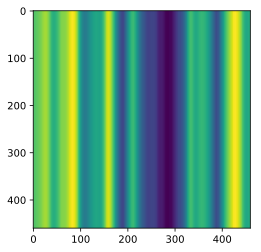

In [18]:
test_flex=getSedimentChangeFlex(eroDep_final2)

import matplotlib.pyplot as plt

plt.imshow(test_flex) #After computation


In [19]:
flexure_ft = test_flex.mean(axis=0)
np.shape(flexure_ft)

(460,)

## Subplot with last step flexure of all sedimentation rate models

In [20]:
# fakeDeflection1 = test_flex.copy()
# fakeDeflection2 = test_flex.copy() + 500
# fakeDeflection3 = test_flex.copy() +1000

HighEro
Ero-Depo loaded
Calculating Flexure HighEro Te = 10000.0
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 10000.0
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 10000.0
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 10000.0
HighEro
Ero-Depo loaded
Calculating Flexure HighEro Te = 50000.0
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 50000.0
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 50000.0
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 50000.0
HighEro
Ero-Depo loaded
Calculating Flexure HighEro Te = 80000.0
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 80000.0
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 80000.0
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 80000.0


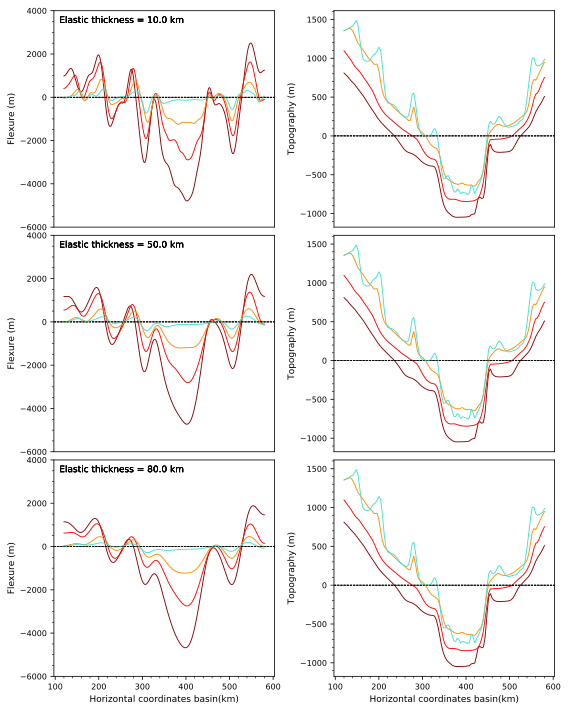

In [174]:
########################################################################################
### MODEL DIRECTORIES
########################################################################################
Models_ls=["SHighEro","HighEro","MedEro","SLowEro"]
Models_labls=["SHighEro","HighEro","MedEro","SLowEro"]
##################################################
Elastic_thicknesses = np.array([10,20,30,40,50,60]) #Tesauro paper.

########################################################################################
Models_ls=["HighEro","MedEro","LowEro2","SLowEro"]
Models_labls=["HighEro","MedEro","LowEro2","SLowEro"]
##################################################
#Elastic_thicknesses = np.array([10,20,30,40,50,60]) #Tesauro paper.


#Models_ls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
#Models_labls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
##################################################
Elastic_thicknesses = np.array([10,30,50,80]) #Tesauro paper.

root_S = "eroAvg_evo_"

#break_ups1=[7.5,17]

#colours=["red","darkmagenta","blue","black","gray"]

#colours=["#8A8183","#F2A055","#D0DE51","#76C79D","#4C64AE","#F16179"]  #one colour for each time step to include
#colourss=["maroon","orangered","blue","turquoise","maroon","red","blue","turquoise"]

#colourss=["black","orange","peru","red","maroon","turquoise"]
#colourss=["orange","peru","red","maroon","turquoise"]

colourss=["maroon","red","darkorange","turquoise","blue"]
##########################################
##########################################
time = 35 #Myr
step = time / 0.2 # 200 Myr is the time step
##########################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = 'Mirror' #'Mirror'
boundary_N = 'Mirror' #'Mirror'
########################################################################

#fig = plt.figure(figsize=(8,9))
#fig = plt.figure(figsize=(8,12)) #for 4
fig = plt.figure(figsize=(8,10)) #for 3

Elastic_thicknesses = np.array([10,50,80])*1e3 #Tesauro paper. In Kilometers

ct=0
for Te in Elastic_thicknesses:
    
    ct2=0
    for model in Models_ls:
        print(model)
        ####### GET DATA
        #allData=getPoints_AllTimesXYZ(dataFT,model,"/def_slab/",depthC,tracer=1)
        
        #eroDep, MinEroDep, MaxEroDep= compute_EroDepo_Elev(dataFT,model,"eroAvg_evo_",580.,120.)[0:3]

        #elevation, MinElev, MaxElev, Xnew_ = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)[4:]
        
        (eroDep, MinEroDep, MaxEroDep, Nsteps,
         elevation, MinElev, MaxElev, Xnew_) = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)
         
    

        
#         timeCurrents=[]
#         maxCurvatures=[]
        ######################################################################################################
        ### Calculating the flexure
        x_coordinates = Xnew_
        
        eroDep_aux = eroDep[int(step)] #Select the desired time in the model
        elevation_aux = elevation[int(step)] #Select the desired time in the model
        
        eroDep_grid=np.tile(eroDep_aux.copy(), 
                      len(eroDep_aux)).reshape(len(eroDep_aux),len(eroDep_aux))
        
        print("Calculating Flexure {0} Te = {1}".format(model,str(Te)))
        flexure_ = getSedimentChangeFlex(eroDep_grid, ElThick=Te,
                                        boundary_W=boundary_W,
                                        boundary_E=boundary_E,
                                        boundary_S=boundary_S,
                                        boundary_N=boundary_N)
        
        #print("Flexure Calculated")
        
        #Averaged along the z axis to get a profile. 
        flexure_f = flexure_.mean(axis=0)
        
        #### PLOTTING BOTH THE FLEXURE AND THE TOPOGRAPHY IN THE BASIN
        
        #if ct % 2 == 0:
        seed=fig.add_subplot(3,2,ct+1) ### 1 plot for the different depths
            
        ### CONFIG PLOT
        anchored_title=AnchoredText('Elastic thickness = {0} km'.format(str(Te/1000)),loc='upper left',
                                    pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
        seed.add_artist(anchored_title)

        ## HERE THE FlEXURE IS PLOT
        #Plot after all curvatures and times are detected
        seed.plot(x_coordinates,flexure_f,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        seed.set_ylabel("Flexure (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)
        seed.set_ylim(-6000,4000)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        #seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        
        #####DELETE NOT USED TICKS -Y axis
        if (ct+1) <= (6-2):
            #print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")
            
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())

        ######################################################################################################
        ## HERE THE TOPOGRAPHY IS PLOT
        seed=fig.add_subplot(3,2,ct+2) ### 1 plot for the different depths
        
        seed.plot(x_coordinates,elevation_aux,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        seed.set_ylabel("Topography (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)
        
        #####DELETE NOT USED TICKS -Y axis
        if (ct+1) <= (6-2):
            #print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")
            
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())

#         #seed.legend(prop={'size': 9})

#         ############ Legend outside
#         if (ct+1)==3:
#             seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=6,
#             borderaxespad=0, frameon=True,title="Sedimentation rates")
            
            #seed.set_ylim(0.,520)
        ###########

        #seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    

        ###### #######################################################################
        ct2=ct2+1
        
    ct=ct+2

    fig.tight_layout()
    #fig.subplots_adjust(hspace=0.038,wspace=0.038)
    fig.subplots_adjust(hspace=0.038,wspace=0.27)
    
    #fig.subplots_adjust(hspace=0.038)
#fig

In [175]:
fig.savefig(saveDir+'Fig_X_Flexure_test.pdf')

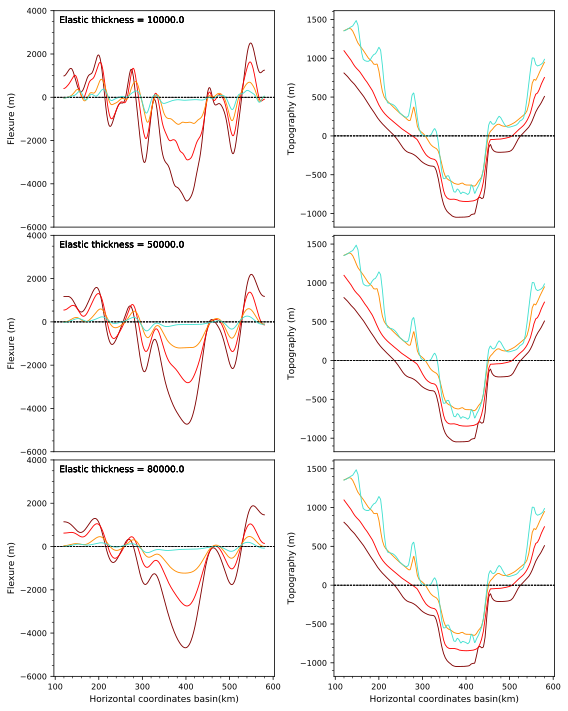

In [171]:
fig


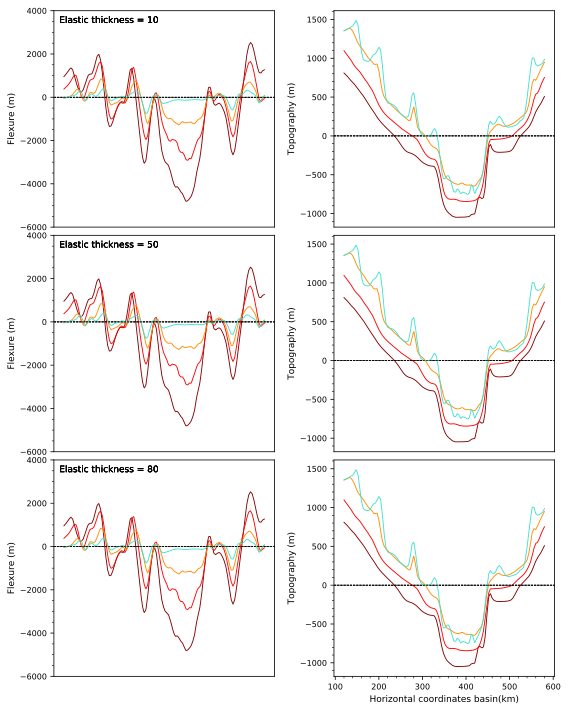

In [162]:
fig

HighEro
Ero-Depo loaded
Calculating Flexure HighEro Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
HighEro
Ero-Depo loaded
Calculating Flexure HighEro Te = 30
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 30
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 30
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
SLowEro
Ero-Depo loaded


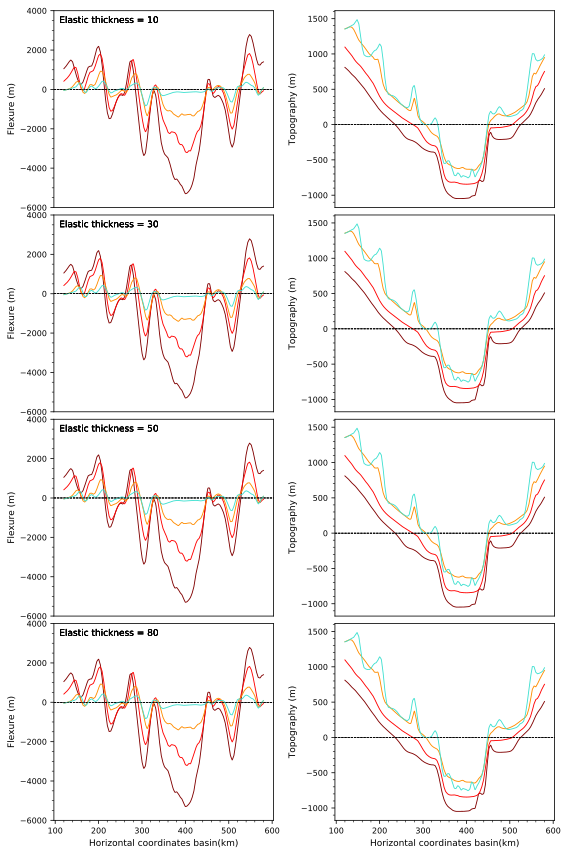

In [158]:
########################################################################################
### MODEL DIRECTORIES
########################################################################################
Models_ls=["SHighEro","HighEro","MedEro","LowEro2","SLowEro"]
Models_labls=["SHighEro","HighEro","MedEro","SLowEro"]
##################################################
Elastic_thicknesses = np.array([10,20,30,40,50,60]) #Tesauro paper.


#Models_ls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
#Models_labls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
##################################################
Models_ls=["HighEro","MedEro","LowEro2","SLowEro"]
Models_labls=["HighEro","MedEro","LowEro2","SLowEro"]
Elastic_thicknesses = np.array([10,30,50,80]) #Tesauro paper.

root_S = "eroAvg_evo_"

#break_ups1=[7.5,17]

#colours=["red","darkmagenta","blue","black","gray"]

#colours=["#8A8183","#F2A055","#D0DE51","#76C79D","#4C64AE","#F16179"]  #one colour for each time step to include
#colourss=["maroon","orangered","blue","turquoise","maroon","red","blue","turquoise"]

#colourss=["black","orange","peru","red","maroon","turquoise"]
#colourss=["orange","peru","red","maroon","turquoise"]

colourss=["maroon","red","darkorange","turquoise","black"]
##########################################
##########################################
time = 35 #Myr
step = time / 0.2 # 200 Myr is the time step
##########################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = 'Mirror' #'Mirror'
boundary_N = 'Mirror' #'Mirror'
########################################################################

#fig = plt.figure(figsize=(8,9))
fig = plt.figure(figsize=(8,12))

ct=0
for Te in Elastic_thicknesses:
    
    ct2=0
    for model in Models_ls:
        print(model)
        ####### GET DATA
        #allData=getPoints_AllTimesXYZ(dataFT,model,"/def_slab/",depthC,tracer=1)
        
        #eroDep, MinEroDep, MaxEroDep= compute_EroDepo_Elev(dataFT,model,"eroAvg_evo_",580.,120.)[0:3]

        #elevation, MinElev, MaxElev, Xnew_ = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)[4:]
        
        (eroDep, MinEroDep, MaxEroDep, Nsteps,
         elevation, MinElev, MaxElev, Xnew_) = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)
#         timeCurrents=[]
#         maxCurvatures=[]
        ######################################################################################################
        ### Calculating the flexure
        x_coordinates = Xnew_
        
        eroDep_aux = eroDep[int(step)] #Select the desired time in the model
        elevation_aux = elevation[int(step)] #Select the desired time in the model
        
        eroDep_grid=np.tile(eroDep_aux.copy(), 
                      len(eroDep_aux)).reshape(len(eroDep_aux),len(eroDep_aux))
        
        print("Calculating Flexure {0} Te = {1}".format(model,str(Te)))
#         flexure_ = getSedimentChangeFlex(eroDep_grid, ElThick=Te,
#                                         boundary_W=boundary_W,
#                                         boundary_E=boundary_E,
#                                         boundary_S=boundary_S,
#                                         boundary_N=boundary_N)
        
        print("Flexure Calculated")
        
        #Averaged along the z axis to get a profile. 
        #flexure_f = flexure_.mean(axis=0)
        flexure_f = - eroDep_aux 
        
        #### PLOTTING BOTH THE FLEXURE AND THE TOPOGRAPHY IN THE BASIN
        
       # if ct % 2 == 0:
        print("Flexure plot!")

        seed=fig.add_subplot(len(Models_ls),2,ct+1) ### 1 plot for the different depths

        ### CONFIG PLOT
        anchored_title=AnchoredText('Elastic thickness = {0}'.format(str(Te)),loc='upper left',
                                    pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
        seed.add_artist(anchored_title)

        ## HERE THE FlEXURE IS PLOT
        #Plot after all curvatures and times are detected
        seed.plot(x_coordinates,flexure_f,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        #seed.invert_yaxis()

        seed.set_ylabel("Flexure (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)
        seed.set_ylim(-6000,4000)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        #seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        #####DELETE NOT USED TICKS -Y axis
        
        
        if (ct+1) <= (8-2):
            print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")

        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())
         
        
        #else:
            
        print("topography plot!")

        seed=fig.add_subplot(len(Models_ls),2,ct+2) ### 1 plot for the different depths
        ######################################################################################################
        ## HERE THE TOPOGRAPHY IS PLOT
        seed.plot(x_coordinates,elevation_aux,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        seed.set_ylabel("Topography (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)

        
        #####DELETE NOT USED TICKS -Y axis
        if (ct+1) <= (8-2):
            print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")
        
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())
        
#         #seed.legend(prop={'size': 9})

#         ############ Legend outside
#         if (ct+1)==3:
#             seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=6,
#             borderaxespad=0, frameon=True,title="Sedimentation rates")

        #seed.set_ylim(0.,520)
    ###########

        #seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
        ct2=ct2+1
        
    ct=ct+2

    fig.tight_layout()
    #fig.subplots_adjust(hspace=0.038,wspace=0.038)
    fig.subplots_adjust(hspace=0.038,wspace=0.28)
    
    #fig.subplots_adjust(hspace=0.038)
#fig

In [140]:
print(Te)

80


MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 10
Flexure Calculated
Flexure plot!
axis killed  1
topography plot!
axis killed  1
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 50
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te = 50
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
SLowEro
Ero-Depo loaded
Calculating Flexure SLowEro Te = 50
Flexure Calculated
Flexure plot!
axis killed  3
topography plot!
axis killed  3
MedEro
Ero-Depo loaded
Calculating Flexure MedEro Te = 80
Flexure Calculated
Flexure plot!
topography plot!
LowEro2
Ero-Depo loaded
Calculating Flexure LowEro2 Te =

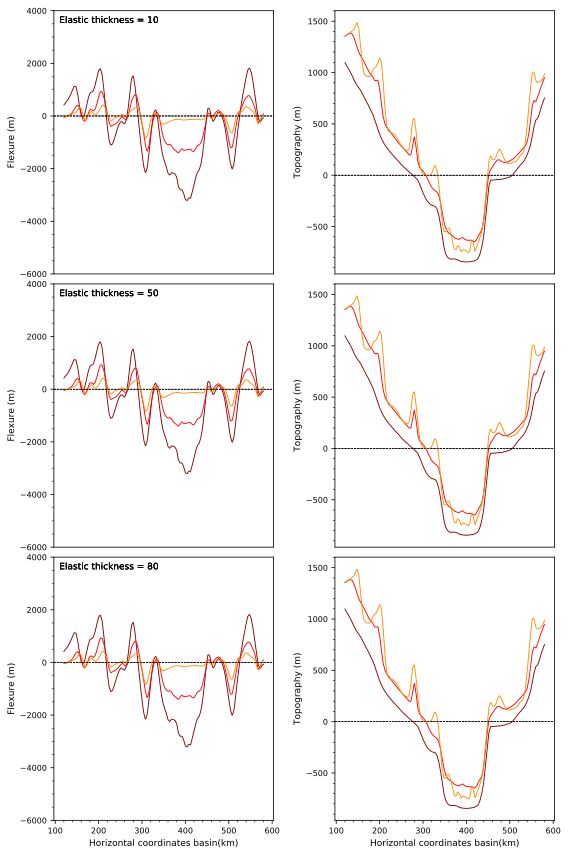

In [166]:
########################################################################################
### MODEL DIRECTORIES
########################################################################################
Models_ls=["SHighEro","HighEro","MedEro","LowEro2","SLowEro"]
Models_labls=["SHighEro","HighEro","MedEro","SLowEro"]
##################################################
Elastic_thicknesses = np.array([10,20,30,40,50,60]) #Tesauro paper.


#Models_ls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
#Models_labls=["SHighEro","HighEro"]#,"HighEro","MedEro","SLowEro"]
##################################################
Models_ls=["MedEro","LowEro2","SLowEro"]
Models_labls=["MedEro","LowEro2","SLowEro"]
Elastic_thicknesses = np.array([10,50,80]) #Tesauro paper.

root_S = "eroAvg_evo_"

#break_ups1=[7.5,17]

#colours=["red","darkmagenta","blue","black","gray"]

#colours=["#8A8183","#F2A055","#D0DE51","#76C79D","#4C64AE","#F16179"]  #one colour for each time step to include
#colourss=["maroon","orangered","blue","turquoise","maroon","red","blue","turquoise"]

#colourss=["black","orange","peru","red","maroon","turquoise"]
#colourss=["orange","peru","red","maroon","turquoise"]

colourss=["maroon","red","darkorange","turquoise","black"]
##########################################
##########################################
time = 35 #Myr
step = time / 0.2 # 200 Myr is the time step
##########################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = '0Displacement0Slope' #'Mirror'
boundary_N = '0Displacement0Slope' #'Mirror'
########################################################################

########################################################################
#Boundary conditions - Same as before
boundary_W =  'Mirror' #'Mirror'
boundary_E = 'Mirror' #'Mirror'
boundary_S = 'Mirror' #'Mirror'
boundary_N = 'Mirror' #'Mirror'
########################################################################

#fig = plt.figure(figsize=(8,9))
fig = plt.figure(figsize=(8,12))

ct=0
for Te in Elastic_thicknesses:
    
    ct2=0
    for model in Models_ls:
        print(model)
        ####### GET DATA
        #allData=getPoints_AllTimesXYZ(dataFT,model,"/def_slab/",depthC,tracer=1)
        
        #eroDep, MinEroDep, MaxEroDep= compute_EroDepo_Elev(dataFT,model,"eroAvg_evo_",580.,120.)[0:3]

        #elevation, MinElev, MaxElev, Xnew_ = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)[4:]
        
        (eroDep, MinEroDep, MaxEroDep, Nsteps,
         elevation, MinElev, MaxElev, Xnew_) = compute_EroDepo_Elev(dataFT, model,"eroAvg_evo_",580.,120.)
#         timeCurrents=[]
#         maxCurvatures=[]
        ######################################################################################################
        ### Calculating the flexure
        x_coordinates = Xnew_
        
        eroDep_aux = eroDep[int(step)] #Select the desired time in the model
        elevation_aux = elevation[int(step)] #Select the desired time in the model
        
        eroDep_grid=np.tile(eroDep_aux.copy(), 
                      len(eroDep_aux)).reshape(len(eroDep_aux),len(eroDep_aux))
        
        print("Calculating Flexure {0} Te = {1}".format(model,str(Te)))
#         flexure_ = getSedimentChangeFlex(eroDep_grid, ElThick=Te,
#                                         boundary_W=boundary_W,
#                                         boundary_E=boundary_E,
#                                         boundary_S=boundary_S,
#                                         boundary_N=boundary_N)
        
        print("Flexure Calculated")
        
        #Averaged along the z axis to get a profile. 
        #flexure_f = flexure_.mean(axis=0)
        flexure_f = - eroDep_aux 
        
        #### PLOTTING BOTH THE FLEXURE AND THE TOPOGRAPHY IN THE BASIN
        
       # if ct % 2 == 0:
        print("Flexure plot!")

        seed=fig.add_subplot(len(Models_ls),2,ct+1) ### 1 plot for the different depths

        ### CONFIG PLOT
        anchored_title=AnchoredText('Elastic thickness = {0}'.format(str(Te)),loc='upper left',
                                    pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
        seed.add_artist(anchored_title)

        ## HERE THE FlEXURE IS PLOT
        #Plot after all curvatures and times are detected
        seed.plot(x_coordinates,flexure_f,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        #seed.invert_yaxis()

        seed.set_ylabel("Flexure (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)
        seed.set_ylim(-6000,4000)
        #seed.set_title("Tectonic Subsidence back-arc basin")
        #seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        #seed.axhline(y=-200.,linestyle='--',color="black",lw='0.6')
        #####DELETE NOT USED TICKS -Y axis
        
        
        if (ct+1) <= (6-2):
            print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")

        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())
         
        
        #else:
            
        print("topography plot!")

        seed=fig.add_subplot(len(Models_ls),2,ct+2) ### 1 plot for the different depths
        ######################################################################################################
        ## HERE THE TOPOGRAPHY IS PLOT
        seed.plot(x_coordinates,elevation_aux,color=colourss[ct2],label='{0}'.format((model)),
                  linewidth=0.9)

        seed.set_ylabel("Topography (m)", fontsize=9)
        seed.set_xlabel("Horizontal coordinates basin(km)", fontsize=9)

        
        #####DELETE NOT USED TICKS -Y axis
        if (ct+1) <= (6-2):
            print("axis killed ", ct+1)
            seed.set_xticks([])
            seed.set_xlabel("")
        
        seed.axhline(y=0.,linestyle='--',color="black",lw='0.6')
        seed.tick_params(axis='both', which='major', labelsize=8)
        seed.xaxis.set_minor_locator(AutoMinorLocator())
        seed.yaxis.set_minor_locator(AutoMinorLocator())
        
#         #seed.legend(prop={'size': 9})

#         ############ Legend outside
#         if (ct+1)==3:
#             seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=6,
#             borderaxespad=0, frameon=True,title="Sedimentation rates")

        #seed.set_ylim(0.,520)
    ###########

        #seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
        ct2=ct2+1
        
    ct=ct+2

    fig.tight_layout()
    #fig.subplots_adjust(hspace=0.038,wspace=0.038)
    fig.subplots_adjust(hspace=0.038,wspace=0.28)
    
    #fig.subplots_adjust(hspace=0.038)
#fig